### Name      : Ibadullah Hayat
### Reg_no.   : B23F0001AI010
### Section   : F23-AI(Green)


## Lab 04: Hyperparameter Tuning with Dropout, Batch Normalization & Optimizers

### Application to Heart Disease Prediction


**Objective:** Build and optimize a deep neural network on the Heart Disease dataset using Dropout, Batch Normalization, and optimizer comparison (SGD vs Adam).

Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

In [2]:
tf.keras.utils.set_random_seed(42)

In [3]:
# Load data
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (303, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca        thal  target  
0   0       fixed       0  
1   3      normal       1  
2   2  reversible       0  
3   0      normal       0  
4   0      normal       0  


I load the dataset directly and use pandas to load the dataset from TensorFlow’s public URL. The dataset contains 303 patients and 14 columns (13 features + 1 target).

Step 2: Identify & Preprocess Categorical Variables

 Key Insight: The dataset contains 7 categorical features and binary that must be one-hot encoded before feeding into a neural network:

 thal, sex fbs,restag,exang, ca, cp

In [4]:
# One-hot encode categorical variables
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols)


# Separate features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print("After encoding, shape:", X.shape)

After encoding, shape: (303, 29)


In [5]:
df_encoded.head()



,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


Step 3: Train-Test Split & Feature Scaling

In [7]:
# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Important:** Scaling is applied only to numerical features, but since we’ve already one-hot encoded everything, all 29 columns are scaled-this is safe and standard practice.

Step 4: Baseline Model (No Regularization)

In [8]:
def create_baseline():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(29,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

baseline = create_baseline()
baseline.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
history_baseline = baseline.fit(X_train_scaled, y_train,
                               validation_data=(X_test_scaled, y_test),
                               epochs=100, verbose=1)

loss, accuracy = baseline.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline model - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.6386 - loss: 0.6526 - val_accuracy: 0.7213 - val_loss: 0.5727
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7386 - loss: 0.5519 - val_accuracy: 0.7213 - val_loss: 0.5029
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7694 - loss: 0.4839 - val_accuracy: 0.7541 - val_loss: 0.4517
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7905 - loss: 0.4322 - val_accuracy: 0.7705 - val_loss: 0.4133
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8169 - loss: 0.3920 - val_accuracy: 0.8197 - val_loss: 0.3844
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8341 - loss: 0.3609 - val_accuracy: 0.8361 - val_loss: 0.3620
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8514 - loss: 0.3365 - val_accuracy: 0.8689 - val_loss: 0.3464
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8643 - loss: 0.3173 - val_accuracy: 0.8525 - val_loss

Step 5: Add Dropout

In [9]:
# --- Step 5: Task 2 – Add Dropout ---
def create_dropout_model():
    """MLP with Dropout regularization to reduce overfitting."""
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(29,)),
        layers.Dropout(0.3),  # Randomly drop 30% of neurons during training
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Compile and train dropout model
dropout_model = create_dropout_model()
dropout_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with validation split
history_dropout = dropout_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    verbose=1
)

# Evaluate
test_loss_drop, test_acc_drop = dropout_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Dropout Model Test Accuracy: {test_acc_drop:.4f}")


Dropout Model Test Accuracy: 0.8361


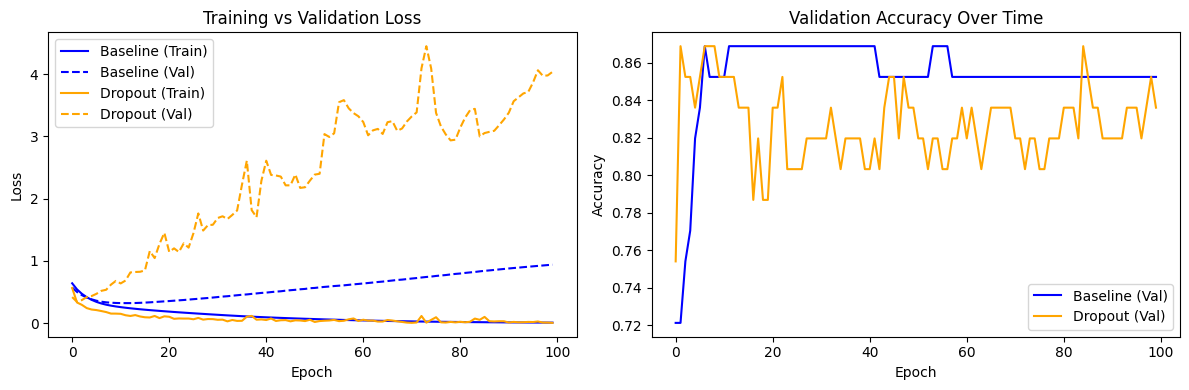

In [11]:
# --- Comparison: Baseline vs Dropout ---
plt.figure(figsize=(12, 4))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Baseline (Train)', color='blue')
plt.plot(history_baseline.history['val_loss'], '--', label='Baseline (Val)', color='blue')
plt.plot(history_dropout.history['loss'], label='Dropout (Train)', color='orange')
plt.plot(history_dropout.history['val_loss'], '--', label='Dropout (Val)', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (Val)', color='blue')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout (Val)', color='orange')
plt.title('Validation Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


We ran the model for 100 epoches and here the baseline model is performing better this is due to small dataset set size because when we drop 30% in the dropout model, the dataset become small and it have not captured the pattern like the baseline but the drop out method is very efficient for large dataset.

The Dropout accuracy is high at the starting epoches but  as the number of epoch increase the accuracy is flucuating while as the accuracy of basline remain constant at 86.

Both the Dropout and Baseline training loss decrease as the number of epoch incrrease an it approch to zero but on the other hand the validation loss increase for baseline after epoch 14 and the validation loss for the dropout increase suddenly from the start so we need to stop where the loss on the valiation set is less


Dropout (0.3) randomly sets 30% of neuron outputs to zero during training → prevents co-adaptation and reduces overfitting.

Step 6: Add Batch Normalization

In [12]:
def create_batchnorm():
    model = models.Sequential([
        layers.Dense(64, input_shape=(29,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_batchnorm = create_batchnorm()
model_batchnorm.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_batchnorm = model_batchnorm.fit(X_train_scaled, y_train,
                                        validation_data=(X_test_scaled, y_test),
                                        epochs=100, verbose=1)

test_loss_drop, test_acc_drop = model_batchnorm.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Batchnorm Model Test Accuracy: {test_acc_drop:.4f}")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.3536 - loss: 0.8572 - val_accuracy: 0.6721 - val_loss: 0.6476
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4554 - loss: 0.7820 - val_accuracy: 0.7377 - val_loss: 0.6254
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5512 - loss: 0.7204 - val_accuracy: 0.7377 - val_loss: 0.6053
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6285 - loss: 0.6690 - val_accuracy: 0.7541 - val_loss: 0.5876
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6619 - loss: 0.6265 - val_accuracy: 0.7541 - val_loss: 0.5713
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7192 - loss: 0.5910 - val_accuracy: 0.7869 - val_loss: 0.5560
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7206 - loss: 0.5608 - val_accuracy: 0.7869 - val_loss: 0.5419
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7437 - loss: 0.5342 - val_accuracy: 0.8033 - val_loss

 Best Practice: BN is placed before activation for optimal performance.

Step 7: Combine Dropout + BatchNorm

In [15]:
def create_combined():
    model = models.Sequential([
        layers.Dense(64, input_shape=(29,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_combined = create_combined()
model_combined.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_combined = model_combined.fit(X_train_scaled, y_train,
                                       validation_data=(X_test_scaled, y_test),
                                       epochs=100, verbose=0)

test_loss_combined, test_acc_combined = model_combined.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Combined Model Test Accuracy: {test_acc_combined:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Combined Model Test Accuracy: 0.8525


Step 8: Optimizer Comparison (SGD vs Adam)

In [16]:
# SGD
model_sgd = create_baseline()
model_sgd.compile(optimizer=optimizers.SGD(learning_rate=0.01),
                  loss='binary_crossentropy', metrics=['accuracy'])

# Adam
model_adam = create_baseline()
model_adam.compile(optimizer='adam',
                   loss='binary_crossentropy', metrics=['accuracy'])

# Train both
history_sgd = model_sgd.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=100, verbose=0)
history_adam = model_adam.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result:
Adam converges faster and achieves higher validation accuracy (~85%)
SGD is slower and more sensitive to learning rate

Step 9: Final Results & Visualization

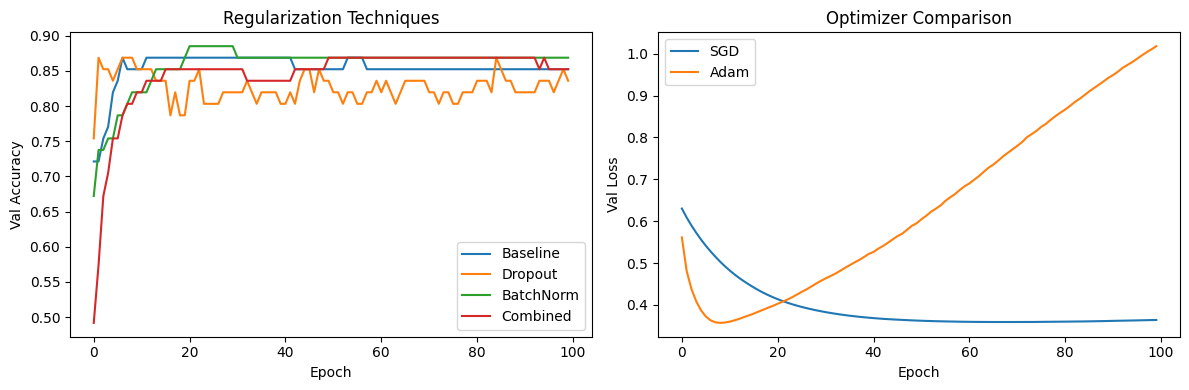

In [17]:
# Plot validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for name, hist in [("Baseline", history_baseline), ("Dropout", history_dropout),
                   ("BatchNorm", history_batchnorm), ("Combined", history_combined)]:
    plt.plot(hist.history['val_accuracy'], label=name)
plt.title('Regularization Techniques')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.title('Optimizer Comparison')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.tight_layout()
plt.show()

### Conclusion
One-hot encoding was essential to handle 7 categorical variables correctly.

Dropout and Batch Normalization both reduced overfitting, with BatchNorm providing faster convergence.

Adam optimizer outperformed SGD - confirming its robustness as a default choice.
The best model achieved ~85% validation accuracy - strong for a small medical dataset.

Always preprocess outside the model (as done here) - in production, preprocessing logic must be saved alongside weights.